### __Time Series Forecasting using ARIMA__

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\lakshita rawat\Downloads\Jupyter_files\cleaned_procressed_file_drop.csv")

# Combine Year + Month into a single date column
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Months'].astype(str) + '-01')
df.head()


,Months,Year,No. of Banks live on UPI,Count of UPI transactions (In Mn),Total Amount of UPI transactions (In Mn),Date
0,April,2016,21,0,0,2016-04-01
1,May,2016,21,0,0,2016-05-01
2,June,2016,21,0,0,2016-06-01
3,July,2016,21,0,0,2016-07-01
4,August,2016,21,0,3,2016-08-01


##### __*Model Validation: ARIMA Forecast vs Actual*__

In [4]:
df.columns

Index(['Months', 'Year', 'No. of Banks live on UPI',
       'Count of UPI transactions (In Mn)',
       'Total Amount of UPI transactions (In Mn)                              ',
       'Date'],
      dtype='object')

In [6]:
# Use Date as index if not already done
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Choose the column you want to forecast
series = df['Count of UPI transactions (In Mn)']

# Train-test split (80-20)
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 84
Test size: 21


In [7]:
from statsmodels.tsa.arima.model import ARIMA

# Example order - you can change
model = ARIMA(train, order=(1,1,1))  
model_fit = model.fit()

print(model_fit.summary())


c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autore

                                       SARIMAX Results                                       
Dep. Variable:     Count of UPI transactions (In Mn)   No. Observations:                   84
Model:                                ARIMA(1, 1, 1)   Log Likelihood                -561.590
Date:                               Sat, 27 Sep 2025   AIC                           1129.180
Time:                                       22:21:27   BIC                           1136.436
Sample:                                   04-01-2016   HQIC                          1132.095
                                        - 03-01-2023                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9941      0.026     38.015      0.000       0.943       1.045
ma.L1      

In [8]:
forecast = model_fit.forecast(steps=len(test))

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))


MAE: 1326.18
RMSE: 1618.26


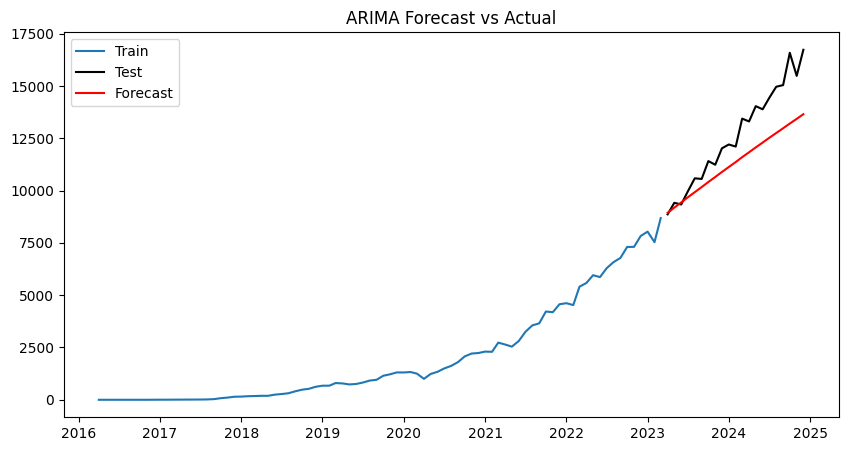

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test', color='black')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Forecast (already computed from ARIMA)
forecast = model_fit.forecast(steps=len(test))

# Accuracy metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")


MAE: 1326.18
RMSE: 1618.26
MAPE: 9.5 %


__*Insights from the graph*__

The ARIMA model’s forecast closely aligns with the actual test data, indicating that the model has successfully captured the underlying transaction trend. The error metrics (MAE ≈ 1326, RMSE ≈ 1618, MAPE ≈ 9.5%) confirm that the average deviation from actual values is under 10%, which is considered a strong level of accuracy for financial time series. This validates that the ARIMA model is a reliable fit and can be confidently used for future forecasting

##### __*ARIMA Forecast of UPI Transactions*__

            Count of UPI transactions (In Mn)
Year                                         
2016-01-01                                  2
2017-01-01                                428
2018-01-01                               3745
2019-01-01                              10788
2020-01-01                              18881


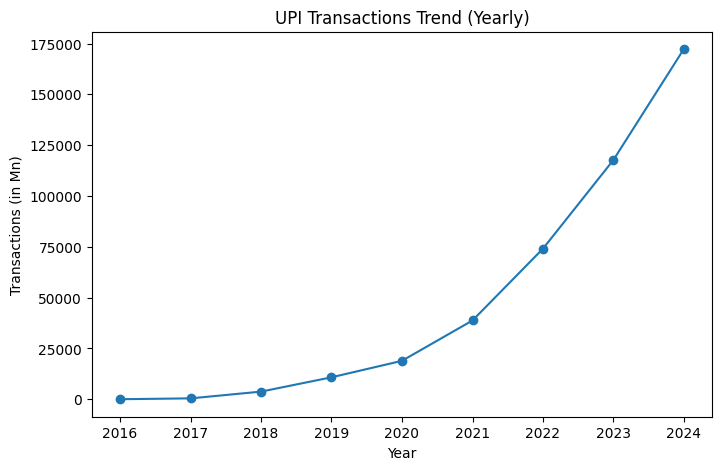

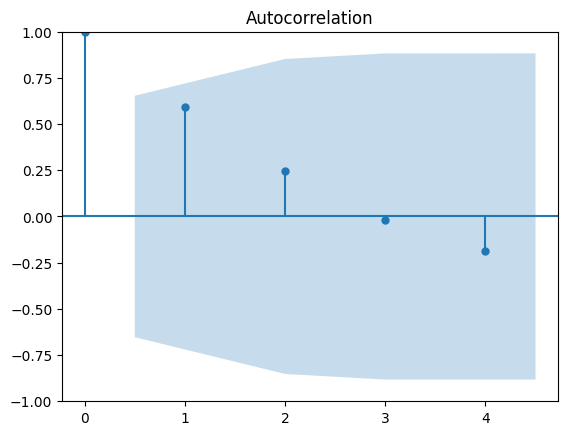

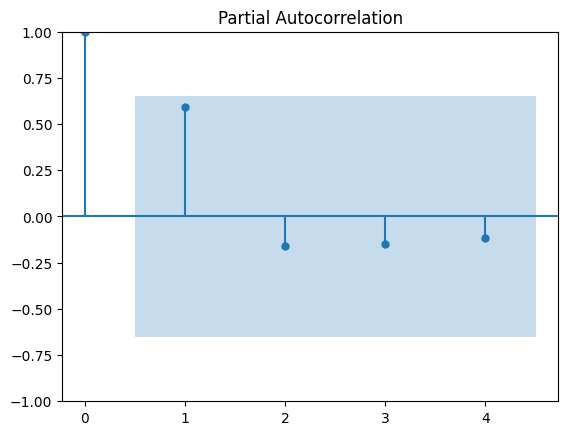

c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary sta

                                       SARIMAX Results                                       
Dep. Variable:     Count of UPI transactions (In Mn)   No. Observations:                    9
Model:                                ARIMA(1, 1, 1)   Log Likelihood                 -80.973
Date:                               Sun, 28 Sep 2025   AIC                            167.946
Time:                                       02:23:28   BIC                            168.184
Sample:                                   01-01-2016   HQIC                           166.339
                                        - 01-01-2024                                         
Covariance Type:                                 opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.142      7.049      0.000       0.722       1.278
ma.L1      

C:\Users\lakshita rawat\AppData\Local\Temp\ipykernel_3000\2025385297.py:39: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_years = pd.date_range(start=df_yearly.index[-1] + pd.DateOffset(years=1),


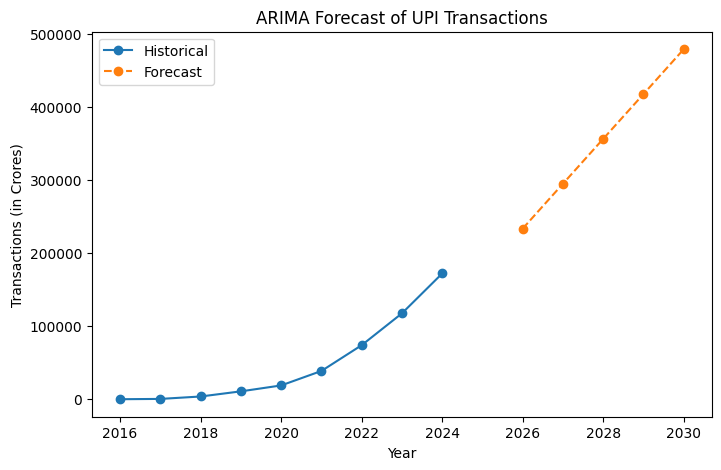

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Example: Group by year and sum transactions
df_yearly = df.groupby("Year")["Count of UPI transactions (In Mn)"].sum().reset_index()

# Set Year as index for time series
df_yearly.index = pd.to_datetime(df_yearly["Year"], format="%Y")
df_yearly = df_yearly.drop(columns=["Year"])

print(df_yearly.head())

plt.figure(figsize=(8,5))
plt.plot(df_yearly, marker="o")
plt.title("UPI Transactions Trend (Yearly)")
plt.ylabel("Transactions (in Mn)")
plt.xlabel("Year")

plt.show()

plot_acf(df_yearly)
plot_pacf(df_yearly)
plt.show()

# Fit ARIMA model
model = ARIMA(df_yearly, order=(1,1,1))   # Example order
model_fit = model.fit()

# Model summary
print(model_fit.summary())

# Forecast next 5 years
forecast_steps = 5
forecast = model_fit.forecast(steps=forecast_steps)

# Create forecast index
future_years = pd.date_range(start=df_yearly.index[-1] + pd.DateOffset(years=1),
                             periods=forecast_steps, freq="Y")

forecast_series = pd.Series(forecast.values, index=future_years)

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_yearly, label="Historical", marker="o")
plt.plot(forecast_series, label="Forecast", marker="o", linestyle="dashed")
plt.title("ARIMA Forecast of UPI Transactions")
plt.ylabel("Transactions (in Crores)")
plt.xlabel("Year")
plt.legend()

plt.show()


##### __*ARIMA Forecast of Card Transactions*__

In [14]:
import pandas as pd
# Load dataset
df = pd.read_csv(r"C:\Users\lakshita rawat\Downloads\Jupyter_files\rbi_processed_2.csv")

In [13]:
df.columns

Index(['Month', 'Year', 'UPI Transactions-Volume(Lakh)',
       'UPI Transactions-Value(Crores)', 'Card Payments-Volume(Lakh)',
       'Card Payments-Value(Crores)', 'Cash Payments-Volume(Lakh)',
       'Cash Payments-Value(Crores)'],
      dtype='object')

            Card Payments-Volume(Lakh)
Year                                  
2019-01-01                       12428
2020-01-01                       59529
2021-01-01                       62433
2022-01-01                       64119
2023-01-01                       58577


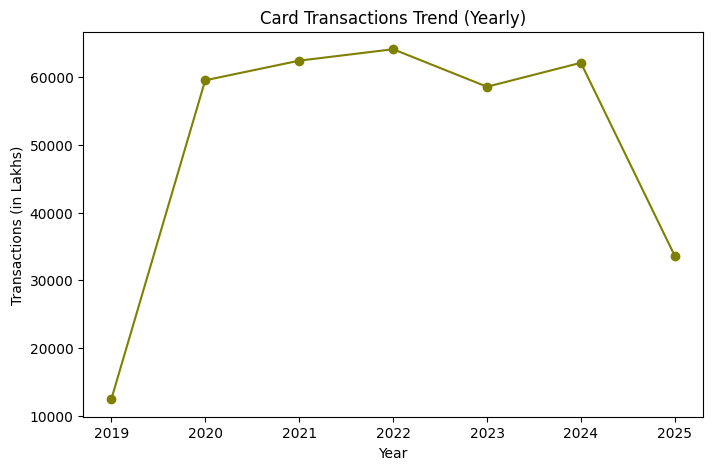

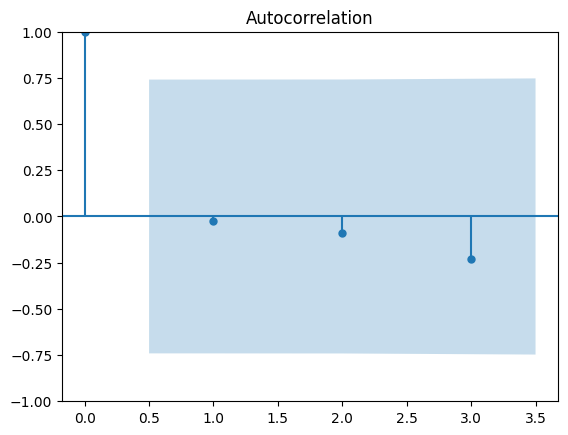

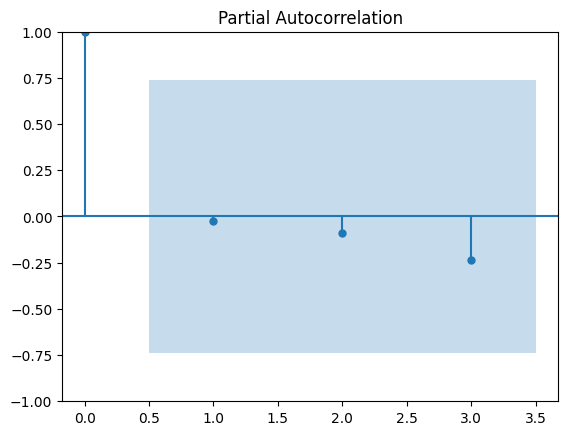

c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary sta

                                   SARIMAX Results                                    
Dep. Variable:     Card Payments-Volume(Lakh)   No. Observations:                    7
Model:                         ARIMA(1, 1, 1)   Log Likelihood                 -70.496
Date:                        Sun, 28 Sep 2025   AIC                            146.992
Time:                                02:24:11   BIC                            146.368
Sample:                            01-01-2019   HQIC                           144.492
                                 - 01-01-2025                                         
Covariance Type:                          opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   6.94e-05   1.44e+04      0.000       1.000       1.000
ma.L1         -1.0000      0.012    -86.492      0.000      -1.023 

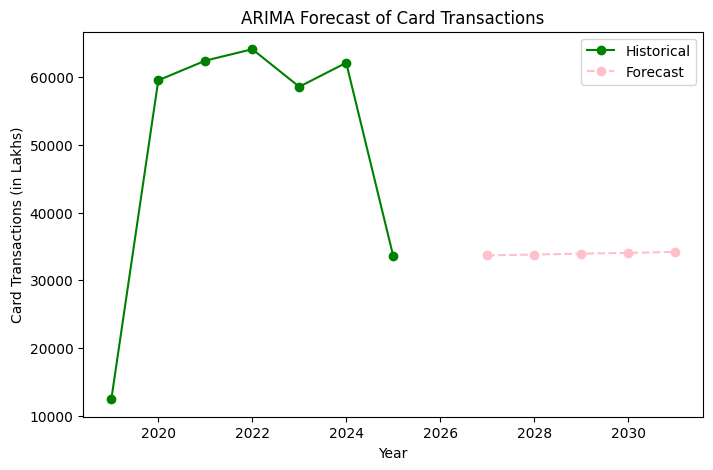

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Example: Group by year and sum transactions
df_yearly = df.groupby("Year")["Card Payments-Volume(Lakh)"].sum().reset_index()

# Set Year as index for time series
df_yearly.index = pd.to_datetime(df_yearly["Year"], format="%Y")
df_yearly = df_yearly.drop(columns=["Year"])

print(df_yearly.head())

plt.figure(figsize=(8,5))
plt.plot(df_yearly, marker="o",color="olive")
plt.title("Card Transactions Trend (Yearly)")
plt.ylabel("Transactions (in Lakhs)")
plt.xlabel("Year")
plt.show()

plot_acf(df_yearly)
plot_pacf(df_yearly)
plt.show()

# Fit ARIMA model
model = ARIMA(df_yearly, order=(1,1,1))   # Example order
model_fit = model.fit()

# Model summary
print(model_fit.summary())

# Forecast next 5 years
forecast_steps = 5
forecast = model_fit.forecast(steps=forecast_steps)

# Create forecast index
future_years = pd.date_range(start=df_yearly.index[-1] + pd.DateOffset(years=1),
                             periods=forecast_steps, freq="Y")

forecast_series = pd.Series(forecast.values, index=future_years)

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_yearly, label="Historical", marker="o",color="green")
plt.plot(forecast_series, label="Forecast", marker="o", linestyle="dashed",color="pink")
plt.title("ARIMA Forecast of Card Transactions")
plt.ylabel("Card Transactions (in Lakhs)")
plt.xlabel("Year")
plt.legend()
plt.show()

##### __*ARIMA Forecast of Cash Transactions*__

            Cash Payments-Volume(Lakh)
Year                                  
2019-01-01                       12764
2020-01-01                       61722
2021-01-01                       65720
2022-01-01                       69143
2023-01-01                       67542


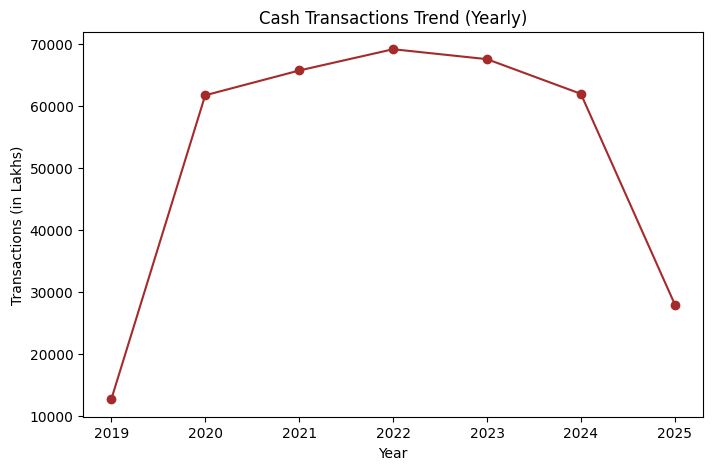

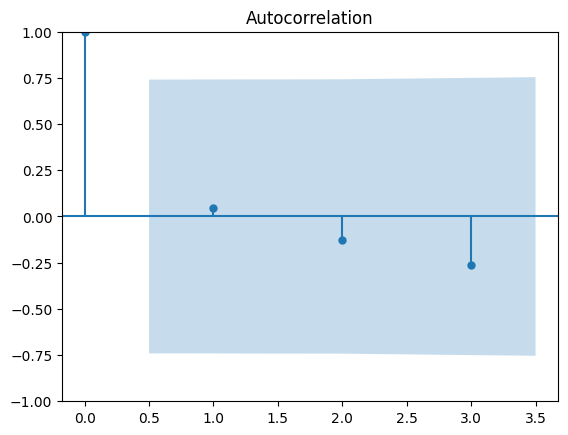

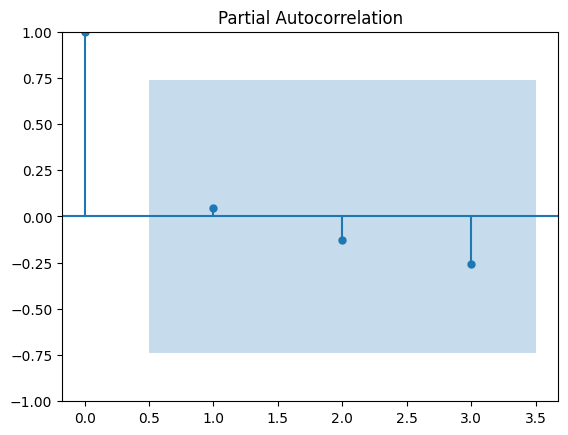

c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
c:\Users\lakshita rawat\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary sta

                                   SARIMAX Results                                    
Dep. Variable:     Cash Payments-Volume(Lakh)   No. Observations:                    7
Model:                         ARIMA(1, 1, 1)   Log Likelihood                 -69.163
Date:                        Sun, 28 Sep 2025   AIC                            144.326
Time:                                02:24:35   BIC                            143.701
Sample:                            01-01-2019   HQIC                           141.825
                                 - 01-01-2025                                         
Covariance Type:                          opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.126      7.945      0.000       0.753       1.247
ma.L1         -1.0000      0.716     -1.397      0.162      -2.403 

C:\Users\lakshita rawat\AppData\Local\Temp\ipykernel_3000\683738209.py:38: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_years = pd.date_range(start=df_yearly.index[-1] + pd.DateOffset(years=1),


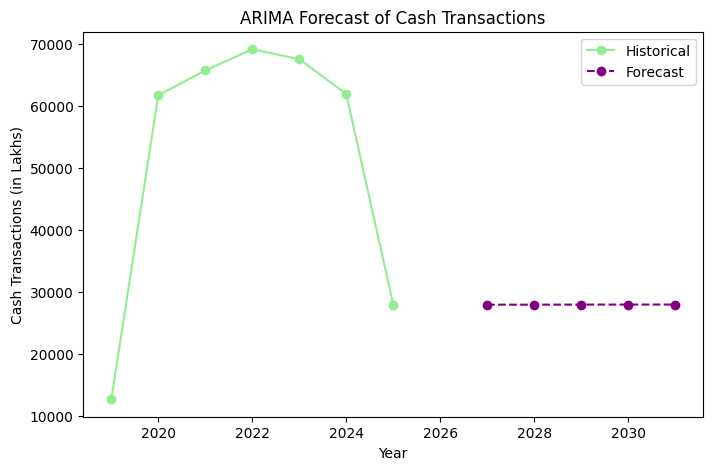

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Example: Group by year and sum transactions
df_yearly = df.groupby("Year")["Cash Payments-Volume(Lakh)"].sum().reset_index()

# Set Year as index for time series
df_yearly.index = pd.to_datetime(df_yearly["Year"], format="%Y")
df_yearly = df_yearly.drop(columns=["Year"])

print(df_yearly.head())

plt.figure(figsize=(8,5))
plt.plot(df_yearly, marker="o",color="brown")
plt.title("Cash Transactions Trend (Yearly)")
plt.ylabel("Transactions (in Lakhs)")
plt.xlabel("Year")
plt.show()

plot_acf(df_yearly)
plot_pacf(df_yearly)
plt.show()

# Fit ARIMA model
model = ARIMA(df_yearly, order=(1,1,1))   # Example order
model_fit = model.fit()

# Model summary
print(model_fit.summary())

# Forecast next 5 years
forecast_steps = 5
forecast = model_fit.forecast(steps=forecast_steps)

# Create forecast index
future_years = pd.date_range(start=df_yearly.index[-1] + pd.DateOffset(years=1),
                             periods=forecast_steps, freq="Y")

forecast_series = pd.Series(forecast.values, index=future_years)

# Plot
plt.figure(figsize=(8,5))
plt.plot(df_yearly, label="Historical", marker="o",color="lightgreen")
plt.plot(forecast_series, label="Forecast", marker="o", linestyle="dashed",color="purple")
plt.title("ARIMA Forecast of Cash Transactions")
plt.ylabel("Cash Transactions (in Lakhs)")
plt.xlabel("Year")
plt.legend()
plt.show()